In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetes_screening_data.csv")

print('Shape : ',df.shape)
print("\nDtypes :\n", df.dtypes)
print('\n Duplicates : \n',df.duplicated().sum())
print('\n Class Balance : \n',df['Outcome'].value_counts(normalize=True))

Shape :  (768, 9)

Dtypes :
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Duplicates : 
 0

 Class Balance : 
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


               zero_count  zero_pct
Glucose                 5       0.7
BloodPressure          35       4.6
SkinThickness         227      29.6
Insulin               374      48.7
BMI                    11       1.4


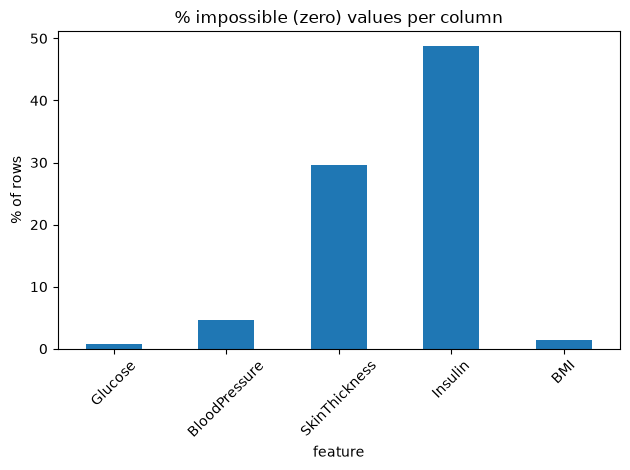

In [6]:
# Columns where 0 is medically impossible (unlike Pregnancies, where 0 is valid)
suspect_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[suspect_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)

audit = pd.DataFrame({"zero_count": zero_counts, "zero_pct": zero_pct})
print(audit)

audit["zero_pct"].plot(kind="bar", title="% impossible (zero) values per column",
                        ylabel="% of rows", xlabel="feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot biologically be zero in a living patient — a value of 0 almost certainly represents a measurement that was not taken, recorded as 0 instead of as missing. Columns with low contamination (Glucose, BloodPressure, BMI) can likely be imputed with simple statistics without much risk. SkinThickness (29.6%) and especially Insulin (48.7%) are missing at a rate high enough that the missingness itself may carry information, and imputation choice here deserves more care — explored further in Phase 4/bonus.